We tested scalability by using the T1 toy dataset as a base pattern and generating larger T1-like workloads from it. Instead of only using the small original example, we kept the same general rhythm of many views followed by frequent Top-k queries, then increased the number of titles and repeated the workload pattern to create bigger datasets.

For each larger dataset, we estimated the total work needed for two designs: a maintained BST and an on-demand heap. The BST was modeled with higher update cost but cheaper Top-k queries, while the heap was modeled with cheaper updates but more expensive queries because the ranking work is done at query time.

We then plotted workload size against total estimated cost using matplotlib. This lets us see how each design grows as the T1-style workload becomes larger, rather than only comparing them on the small toy example.

In [2]:
import sys
!{sys.executable} -m pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 8.1/8.1 MB 43.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 51.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------------------------------------- 7.1/7.1 MB 49.1 MB/s eta 0:00:00

   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ---------

In [3]:
%matplotlib inline

Toy dataset size: 23
Toy dataset summary:
{'events': 23, 'views': 20, 'queries': 3, 'active_titles': 6, 'query_ks': [3, 3, 5]}

Example scaled dataset (first 15 rows):
VIEW,1,S1
VIEW,2,S9
VIEW,3,S7
VIEW,4,S2
VIEW,5,S3
VIEW,6,S3
VIEW,7,S4
VIEW,8,S7
VIEW,9,S1
VIEW,10,S1
VIEW,11,S9
VIEW,12,S3
VIEW,13,S7
VIEW,14,S1
VIEW,15,S3

Toy dataset estimated costs:
{'events': 23, 'views': 20, 'queries': 3, 'active_titles': 6, 'bst_cost': 70.4541375165866, 'heap_cost': 66.43458750793272}

Scaling results:
   events  views  queries  active_titles     bst_cost     heap_cost  \
0      23     20        3              4    57.000000     54.000000   
1      46     40        6             11   181.133854    182.107496   
2      92     80       12             23   460.167700    555.036726   
3     184    160       24             44  1092.535418   1696.429982   
4     368    320       48             85  2534.655864   5528.052805   
5     736    640       96            167  5786.406359  19271.063911   

   num

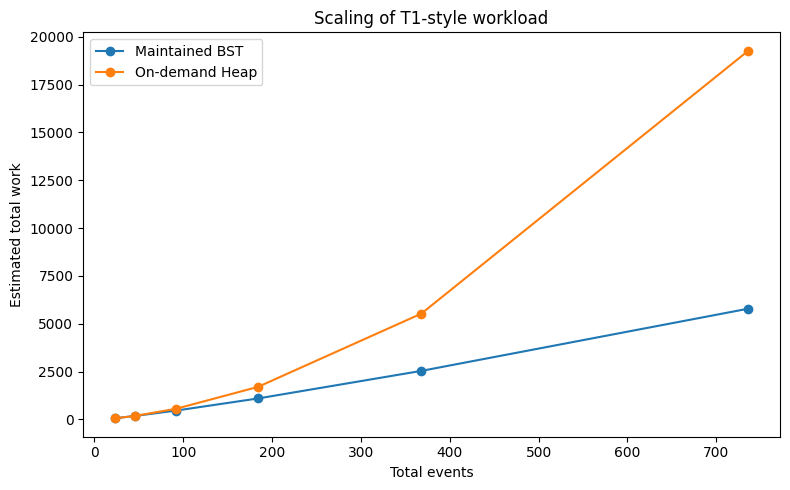

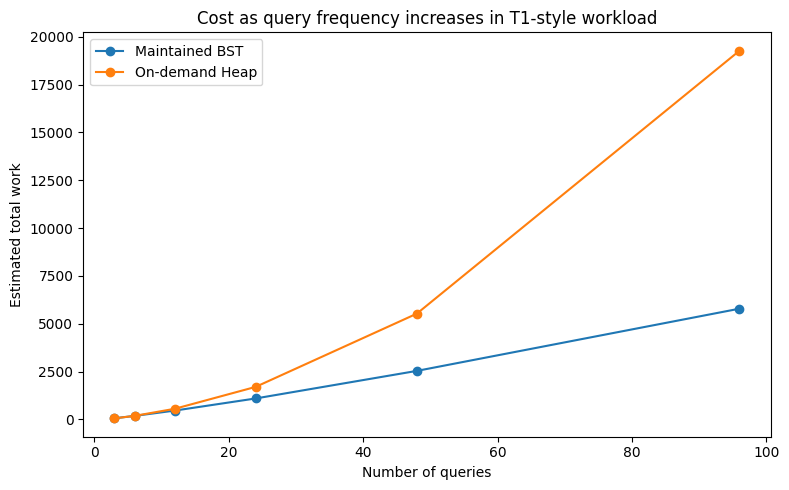

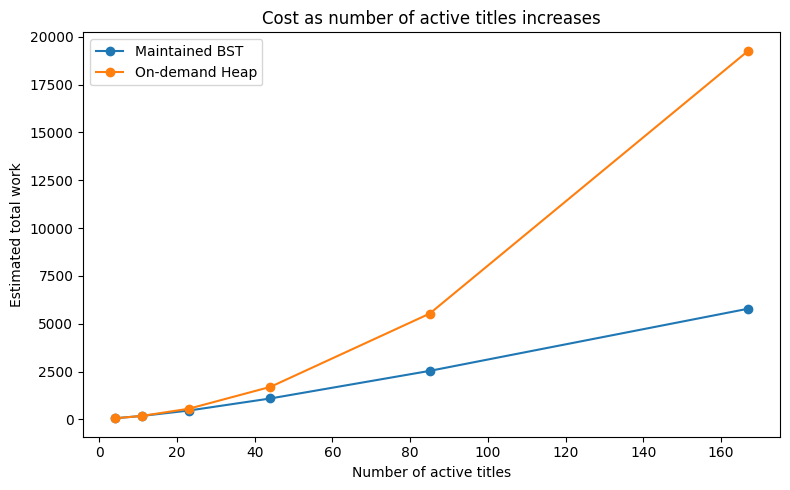

In [4]:
# T1 Scaling Analysis: Maintained BST vs On-Demand Heap
# This script is notebook-friendly: paste each section into separate cells if you want.



import random
import math
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------------
# 1. Original T1 toy dataset from the project brief
# --------------------------------------------------
t1_toy = [
    "VIEW,1,S1",
    "VIEW,2,S2",
    "VIEW,3,S1",
    "VIEW,4,S3",
    "VIEW,5,S2",
    "VIEW,6,S1",
    "VIEW,7,S4",
    "VIEW,8,S2",
    "VIEW,9,S3",
    "VIEW,10,S2",
    "VIEW,11,S5",
    "VIEW,12,S1",
    "VIEW,13,S3",
    "VIEW,14,S2",
    "VIEW,15,S6",
    "QRY,15,3",
    "VIEW,16,S2",
    "VIEW,17,S2",
    "VIEW,18,S3",
    "QRY,18,3",
    "VIEW,19,S1",
    "VIEW,20,S1",
    "QRY,20,5",
]

print("Toy dataset size:", len(t1_toy))


# --------------------------------------------------
# 2. Helper to summarize a dataset
# --------------------------------------------------
def summarize_dataset(dataset):
    active_titles = set()
    num_views = 0
    query_ks = []

    for row in dataset:
        parts = row.split(",")
        if parts[0] == "VIEW":
            num_views += 1
            active_titles.add(parts[2])
        elif parts[0] == "QRY":
            query_ks.append(int(parts[2]))

    return {
        "events": len(dataset),
        "views": num_views,
        "queries": len(query_ks),
        "active_titles": len(active_titles),
        "query_ks": query_ks
    }


print("Toy dataset summary:")
print(summarize_dataset(t1_toy))


# --------------------------------------------------
# 3. Generate larger T1-like datasets
# --------------------------------------------------
def generate_t1_like_dataset(num_titles=30, num_blocks=5, seed=42):
    """
    Generates a larger T1-style workload while preserving the same rhythm:
    15 views -> QRY top 3 -> 3 views -> QRY top 3 -> 2 views -> QRY top 5

    num_titles: number of shows available
    num_blocks: how many times to repeat the T1 rhythm
    """
    random.seed(seed)

    titles = [f"S{i}" for i in range(1, num_titles + 1)]

    # Make some titles hotter than others, similar to how T1 has a few frequent titles
    hot_cutoff = max(3, num_titles // 5)
    weights = [5 if i < hot_cutoff else 1 for i in range(num_titles)]

    pattern = [
        ("views", 15),
        ("qry", 3),
        ("views", 3),
        ("qry", 3),
        ("views", 2),
        ("qry", 5),
    ]

    dataset = []
    t = 1

    for _ in range(num_blocks):
        for step_type, value in pattern:
            if step_type == "views":
                for _ in range(value):
                    title = random.choices(titles, weights=weights, k=1)[0]
                    dataset.append(f"VIEW,{t},{title}")
                    t += 1
            else:
                dataset.append(f"QRY,{t-1},{value}")

    return dataset


sample_scaled = generate_t1_like_dataset(num_titles=12, num_blocks=2, seed=1)
print("\nExample scaled dataset (first 15 rows):")
for row in sample_scaled[:15]:
    print(row)


# --------------------------------------------------
# 4. Cost model
# --------------------------------------------------
def estimate_costs(dataset):
    """
    Cost model used:
    - Maintained BST:
        each view update costs O(log n)
        each Top-k query costs O(log n + k)

    - On-demand heap:
        each view update is treated as cheap O(1) count maintenance
        each query costs O(n + k log n)
        (scan/build from current active titles + extract top-k)
    """
    active_titles = set()
    num_views = 0
    query_ks = []

    for row in dataset:
        parts = row.split(",")
        if parts[0] == "VIEW":
            num_views += 1
            active_titles.add(parts[2])
        elif parts[0] == "QRY":
            query_ks.append(int(parts[2]))

    n = max(2, len(active_titles))
    logn = math.log2(n)

    bst_cost = num_views * logn + sum(logn + k for k in query_ks)
    heap_cost = num_views + sum(n + k * logn for k in query_ks)

    return {
        "events": len(dataset),
        "views": num_views,
        "queries": len(query_ks),
        "active_titles": n,
        "bst_cost": bst_cost,
        "heap_cost": heap_cost,
    }


print("\nToy dataset estimated costs:")
print(estimate_costs(t1_toy))


# --------------------------------------------------
# 5. Run multiple scales
# --------------------------------------------------
scales = [
    {"num_titles": 6, "num_blocks": 1},
    {"num_titles": 12, "num_blocks": 2},
    {"num_titles": 24, "num_blocks": 4},
    {"num_titles": 48, "num_blocks": 8},
    {"num_titles": 96, "num_blocks": 16},
    {"num_titles": 192, "num_blocks": 32},
]

results = []

for s in scales:
    data = generate_t1_like_dataset(
        num_titles=s["num_titles"],
        num_blocks=s["num_blocks"],
        seed=42
    )
    stats = estimate_costs(data)
    stats["num_titles_input"] = s["num_titles"]
    stats["num_blocks"] = s["num_blocks"]
    results.append(stats)

df = pd.DataFrame(results)
print("\nScaling results:")
print(df)


# --------------------------------------------------
# 6. Plot 1: Total events vs total estimated cost
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(df["events"], df["bst_cost"], marker="o", label="Maintained BST")
plt.plot(df["events"], df["heap_cost"], marker="o", label="On-demand Heap")

plt.xlabel("Total events")
plt.ylabel("Estimated total work")
plt.title("Scaling of T1-style workload")
plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 7. Plot 2: Number of queries vs total estimated cost
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(df["queries"], df["bst_cost"], marker="o", label="Maintained BST")
plt.plot(df["queries"], df["heap_cost"], marker="o", label="On-demand Heap")

plt.xlabel("Number of queries")
plt.ylabel("Estimated total work")
plt.title("Cost as query frequency increases in T1-style workload")
plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 8. Plot 3: Active titles vs total estimated cost
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(df["active_titles"], df["bst_cost"], marker="o", label="Maintained BST")
plt.plot(df["active_titles"], df["heap_cost"], marker="o", label="On-demand Heap")

plt.xlabel("Number of active titles")
plt.ylabel("Estimated total work")
plt.title("Cost as number of active titles increases")
plt.legend()
plt.tight_layout()
plt.show()